In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from util import seed_everything, get_m, RandomMasking, prepare_qsm_dataset
from util import mask_crop as mask_crop_fn

# ============================================================
# 1. DEVICE & CONFIG
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

EXP_NAME = "msw_to_chh_manifold_comparison"
N_PCA_COMPONENTS = 128
AUG_FACTOR = 5 
NEG_OVERSAMPLE_FACTOR = 10 
seed_everything(0)

UNLABELED_CHH_PATH = "/media/mts_dbs/chh/nii/q" 

qsm_aug = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    RandomMasking(p=0.3)
])

# ============================================================
# 2. DATA LOADING & EXTRACTION
# ============================================================
print("\n--- Loading Datasets ---")
dataset_msw = prepare_qsm_dataset('MSW', '/media/mts_dbs/dbs/all/nii/qsm_115/im', 
                                  '/media/mts_dbs/dbs/all/nii/seg_ps/',
                                  '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv', 
                                  'msw_cache_ax.pt', load_cache=True, mask_crop_fn=mask_crop_fn)

dataset_chh = prepare_qsm_dataset('CHH', '/media/mts_dbs/chh/nii/qsm/',
                                   '/media/mts_dbs/chh/nii/roi/',
                                    '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv',
                                    'chh_cache_ax.pt', load_cache=True, mask_crop_fn=mask_crop_fn, 
                                    unlabeled_nii_path=UNLABELED_CHH_PATH)

def get_mixed_msw_data(dataset, aug_transform=None, factor=1):
    labeled_imgs, labeled_clins, labels = [], [], []
    unlabeled_imgs, unlabeled_clins = [], []
    
    print(f"Processing {len(dataset)} slices...")
    for idx in tqdm(range(len(dataset))):
        img_orig, clin, lbl, _ = dataset[idx]
        img_np = img_orig.squeeze().numpy() 
        img_flat = img_np.flatten()

        if lbl != -1:
            repeats = NEG_OVERSAMPLE_FACTOR if lbl == 0 else 1
            for _ in range(repeats):
                labeled_imgs.append(img_flat)
                labeled_clins.append(clin.numpy())
                labels.append(lbl)
                if aug_transform and factor > 1:
                    for _ in range(factor - 1):
                        aug_tensor = aug_transform(img_orig.clone())
                        labeled_imgs.append(aug_tensor.squeeze().numpy().flatten())
                        labeled_clins.append(clin.numpy())
                        labels.append(lbl)
        else:
            unlabeled_imgs.append(img_flat)
            unlabeled_clins.append(clin.numpy())

    return (np.array(labeled_imgs, dtype=np.float32), np.array(labeled_clins, dtype=np.float32), 
            np.array(labels), np.array(unlabeled_imgs, dtype=np.float32), np.array(unlabeled_clins, dtype=np.float32))

X_train_img, X_train_clin, y_train, X_un_img, X_un_clin = get_mixed_msw_data(dataset_msw, aug_transform=qsm_aug, factor=AUG_FACTOR)

img_scaler = StandardScaler()
X_train_img_scaled = img_scaler.fit_transform(X_train_img)
X_un_img_scaled = img_scaler.transform(X_un_img)

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0)
pca.fit(np.vstack([X_train_img_scaled, X_un_img_scaled]))

scaler_final = StandardScaler()
X_train_final = scaler_final.fit_transform(np.hstack([pca.transform(X_train_img_scaled), X_train_clin]))

X_test_img_list, X_test_clin_list, y_test_list = [], [], []
target_img_shape = X_train_img.shape[1] 
for i in tqdm(range(len(dataset_chh)), desc="Processing Test Slices"):
    img, clin, lbl, _ = dataset_chh[i]
    if lbl != -1:
        img_np = img.numpy().squeeze()
        if img_np.ndim == 3: img_np = img_np[:, :, img_np.shape[2]//2]
        img_flat = img_np.flatten()
        if img_flat.shape[0] != target_img_shape:
            tmp = np.zeros(target_img_shape)
            tmp[:min(img_flat.size, target_img_shape)] = img_flat[:min(img_flat.size, target_img_shape)]
            img_flat = tmp
        X_test_img_list.append(img_flat); X_test_clin_list.append(clin.numpy()); y_test_list.append(lbl)

X_test_final = scaler_final.transform(np.hstack([pca.transform(img_scaler.transform(np.array(X_test_img_list))), np.array(X_test_clin_list)]))
y_test = np.array(y_test_list)

# ============================================================
# 3. MODELS
# ============================================================
class HybridAE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 64))
        self.decoder = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, input_dim))
        self.classifier_head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x, mode='pretrain'):
        latent = self.encoder(x)
        return self.decoder(latent) if mode == 'pretrain' else self.classifier_head(latent).squeeze()

class SupervisedManifoldAE(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 128), nn.ReLU(), nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, input_dim))
        self.classifier = nn.Sequential(nn.Linear(latent_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x, mode='train'):
        latent = self.encoder(x)
        return self.decoder(latent) if mode == 'pretrain' else self.classifier(latent).squeeze()

# ============================================================
# 4. TRAINING
# ============================================================
model_h = HybridAE(X_train_final.shape[1]).to(device)
model_m = SupervisedManifoldAE(X_train_final.shape[1]).to(device)
X_pre = torch.tensor(X_train_final, dtype=torch.float32).to(device)
pre_loader = DataLoader(TensorDataset(X_pre), batch_size=128, shuffle=True)

# 1. Pretraining with Contrastive Consistency Logic from Script 1
print("Pretraining (Contrastive Consistency)...")
for m in [model_h, model_m]:
    opt = optim.Adam(m.parameters(), lr=1e-3)
    mse_loss = nn.MSELoss()
    m.train()
    for epoch in range(30): # Slightly increased epochs for consistency stabilization
        for b in pre_loader:
            clean = b[0]
            # Create two augmented views in latent space via noise
            v1, v2 = clean + torch.randn_like(clean)*0.05, clean + torch.randn_like(clean)*0.15
            opt.zero_grad()
            z1, z2 = m.encoder(v1), m.encoder(v2)
            # Loss = Reconstruction of v1 + Consistency between z1 and z2
            loss = mse_loss(m.decoder(z1), clean) + 0.5 * mse_loss(z1, z2)
            loss.backward(); opt.step()

# 2. Fine-tuning with Weighted BCE
print("Fine-tuning...")
X_ft, y_ft = torch.tensor(X_train_final, dtype=torch.float32).to(device), torch.tensor(y_train, dtype=torch.float32).to(device)
train_loader = DataLoader(TensorDataset(X_ft, y_ft), batch_size=64, shuffle=True)
for m, lr_rate in [(model_h, 5e-6), (model_m, 1e-5)]:
    opt = optim.Adam(m.parameters(), lr=lr_rate, weight_decay=1e-2)
    for epoch in range(45):
        m.train()
        for bx, by in train_loader:
            opt.zero_grad()
            # weight 10.0 for class 0 (Non-responders) to handle imbalance
            loss = nn.functional.binary_cross_entropy(m(bx, mode='fine_tune'), by, weight=(by==0).float()*10.0+1.0)
            loss.backward(); opt.step()

# ============================================================
# 5. EVALUATION (WITH TRUE CLINICAL-ONLY BASELINE)
# ============================================================
model_h.eval(); model_m.eval()

# 1. Clinical-Only LR (Slicing X to keep only clinical features)
X_train_clin_only = X_train_final[:, N_PCA_COMPONENTS:]
X_test_clin_only = X_test_final[:, N_PCA_COMPONENTS:]
clf_clin = LogisticRegression(class_weight='balanced', max_iter=5000).fit(X_train_clin_only, y_train)

# 2. Clinical + Imaging LR (Hybrid LR)
clf_hybrid_lr = LogisticRegression(class_weight='balanced', max_iter=5000).fit(X_train_final, y_train)

with torch.no_grad():
    t_test = torch.tensor(X_test_final, dtype=torch.float32).to(device)
    p_h = model_h(t_test, mode='fine_tune').cpu().numpy()
    p_m_probs = model_m(t_test, mode='fine_tune').cpu().numpy() 
    
    p_clin_only = clf_clin.predict_proba(X_test_clin_only)[:, 1]
    p_hybrid_lr = clf_hybrid_lr.predict_proba(X_test_final)[:, 1]

# Metric calculation
c_res = get_m(y_test, (p_clin_only >= 0.5), p_clin_only)
h_lr_res = get_m(y_test, (p_hybrid_lr >= 0.5), p_hybrid_lr)
p_res = get_m(y_test, (p_h >= 0.5), p_h)
h_res = get_m(y_test, (p_m_probs >= 0.5), p_m_probs) 

print(f"\n{'Metric':<15} | {'Clin-Only LR':<15} | {'Hybrid LR':<15} | {'Orig HybridAE':<15} | {'Manifold Hybrid'}")
print("-" * 110)
for i, name in enumerate(['Accuracy', 'Sensitivity', 'Specificity', 'AUC']):
    print(f"{name:<15} | {c_res[i]:<15.4f} | {h_lr_res[i]:<15.4f} | {p_res[i]:<15.4f} | {h_res[i]:.4f}")
print("-" * 110)

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


Using device: cuda

--- Loading Datasets ---
Preparing MSW dataset
Loaded cache with 7790 slices.
Finished MSW: 7790 slices.
Responders: 61 | Nonresponders: 5 | Unlabeled: 45
Preparing CHH dataset
Loaded cache with 2664 slices.
Finished CHH: 2664 slices.
Responders: 34 | Nonresponders: 3 | Unlabeled: 0
Processing 7790 slices...


Processing Test Slices: 100%|██████████| 2664/2664 [00:00<00:00, 35563.84it/s]


Pretraining (Contrastive Consistency)...
Fine-tuning...

Metric          | Clin-Only LR    | Hybrid LR       | Orig HybridAE   | Manifold Hybrid
--------------------------------------------------------------------------------------------------------------
Accuracy        | 0.7027          | 0.7305          | 0.3164          | 0.7237
Sensitivity     | 0.7353          | 0.7684          | 0.2561          | 0.7296
Specificity     | 0.3333          | 0.3009          | 1.0000          | 0.6574
AUC             | 0.6176          | 0.6361          | 0.7686          | 0.7648
--------------------------------------------------------------------------------------------------------------


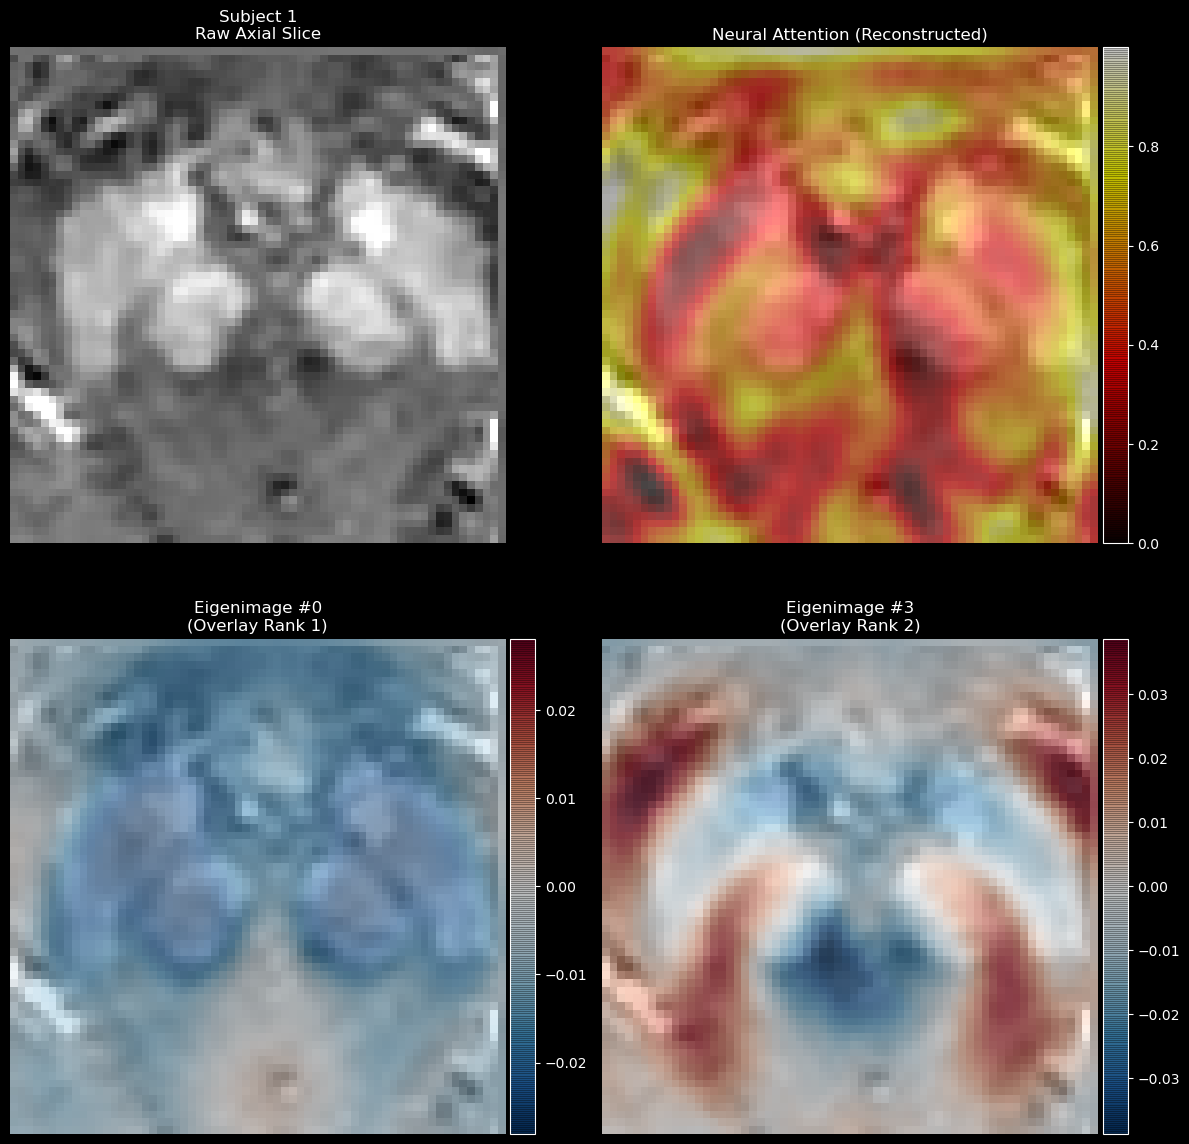

In [2]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_subject_with_eigen_2x2(model,subject_idx=0, dataset=dataset_chh):
    model.eval()
    plt.style.use('dark_background')
    
    # 1. DATA EXTRACTION
    all_sub_ids = sorted(list(set(s['sub_id'] for s in dataset.samples)))
    target_sub_id = all_sub_ids[min(subject_idx, len(all_sub_ids)-1)]
    sub_sample_indices = [i for i, s in enumerate(dataset.samples) if s['sub_id'] == target_sub_id]
    mid_sample_idx = sub_sample_indices[len(sub_sample_indices) // 2]
    
    img_tensor, clin_t, lbl, _ = dataset[mid_sample_idx]
    raw_slice = img_tensor.squeeze().numpy() 
    rotated_raw = np.rot90(raw_slice)
    
    # 2. INFERENCE & GRADIENT TRACKING
    flat = raw_slice.flatten().reshape(1, -1)
    scaled = img_scaler.transform(flat)
    pca_feat = pca.transform(scaled)
    final_in = scaler_final.transform(np.hstack([pca_feat, clin_t.numpy().reshape(1, -1)]))
    
    input_t = torch.tensor(final_in, dtype=torch.float32, device=device).requires_grad_()
    out = model(input_t, mode='fine_tune')
    out.backward()
    
    # 3. COMPONENT IMPORTANCE (Top 2)
    grads = input_t.grad.data.abs().cpu().numpy().squeeze()[:128]
    top_2_indices = np.argsort(grads)[-2:][::-1]
    
    # 4. SALIENCY RECONSTRUCTION
    sal_flat = np.dot(grads, pca.components_)
    sal_2d = sal_flat.reshape(64, 64)
    sal_norm = (sal_2d - sal_2d.min()) / (sal_2d.max() - sal_2d.min() + 1e-8)
    
    # 5. 2x2 DISPLAY
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    def add_aligned_colorbar(ax, im, visible=True):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        if visible:
            plt.colorbar(im, cax=cax)
        else:
            cax.axis('off')

    # [0, 0] Raw Image
    im0 = axes[0, 0].imshow(rotated_raw, cmap='gray')
    axes[0, 0].set_title(f"Subject {target_sub_id}\nRaw Axial Slice")
    add_aligned_colorbar(axes[0, 0], im0, visible=False) 
    
    # [0, 1] Saliency Overlay
    axes[0, 1].imshow(rotated_raw, cmap='gray')
    im_sal = axes[0, 1].imshow(np.rot90(sal_norm), cmap='hot', alpha=0.5)
    axes[0, 1].set_title("Neural Attention (Reconstructed)")
    add_aligned_colorbar(axes[0, 1], im_sal)
    
    # [1, 0] & [1, 1] Top 2 Eigenimages as Overlays
    for i, comp_idx in enumerate(top_2_indices):
        ax_eig = axes[1, i]
        
        # Draw background MRI
        ax_eig.imshow(rotated_raw, cmap='gray')
        
        # Prepare Eigenimage
        eigen_img = pca.components_[comp_idx].reshape(64, 64)
        eigen_rotated = np.rot90(eigen_img)
        v_max = np.abs(eigen_rotated).max()
        
        # Optional: Masking out very low values (near 0) makes the overlay cleaner
        # masked_eigen = np.ma.masked_inside(eigen_rotated, -v_max*0.05, v_max*0.05)
        
        im_eig = ax_eig.imshow(
            eigen_rotated, 
            cmap='RdBu_r', 
            vmin=-v_max, 
            vmax=v_max, 
            alpha=0.5  # Adjust transparency here
        )
        
        ax_eig.set_title(f"Eigenimage #{comp_idx}\n(Overlay Rank {i+1})")
        add_aligned_colorbar(ax_eig, im_eig)
    
    for ax in axes.flatten():
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run it
visualize_subject_with_eigen_2x2(model_m,subject_idx=0, dataset=dataset_chh)